In [2]:
### System Import 
import sys
import os
sys.path.append(os.path.abspath(".."))  

In [3]:
from classes.economy.production_process.production_graph import ProductionGraph
import networkx as nx

from classes.economy.production_process.production_process import ProductionProcess
import matplotlib.pyplot as plt

In [4]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Use Example :
G = nx.DiGraph()
G.add_edges_from([
("Input", "Intermediate"),
("Intermediate", "Final")])



C:\Users\andre\AppData\Local\Temp\ipykernel_20748\1562922502.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


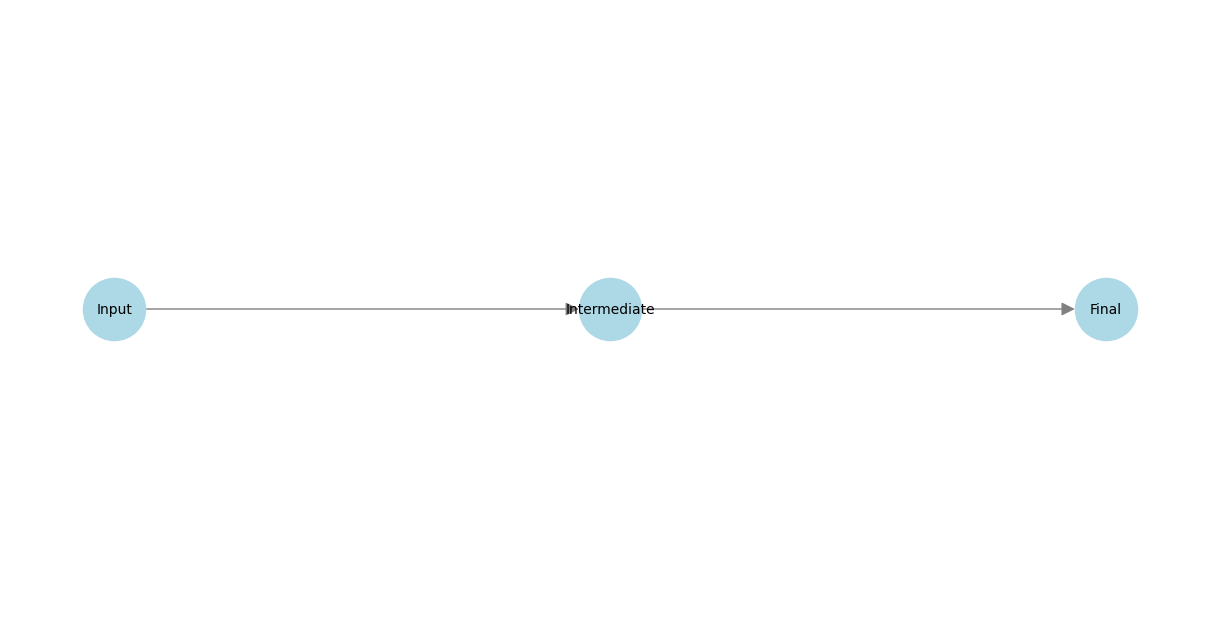

In [6]:
# 1) break G into topological generations (one list per “layer”)
layers = list(nx.topological_generations(G))

# 2) build a position dict that spaces each layer on the x‑axis,
#    and spreads nodes in that same layer along the y‑axis
pos = {}
for x, layer in enumerate(layers):
    n = len(layer)
    # center the layer at y=0, gap of 1
    y_start = (n - 1) / 2
    for i, node in enumerate(layer):
        pos[node] = (x, y_start - i)

# 3) draw with a bigger figure, arrows and labels
plt.figure(figsize=(12, 6))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=2000,
    font_size=10,
    arrowsize=20,
    arrowstyle='-|>'
)
plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
plan = [0,1,0,1,1,0,0,0,1,1,1]

In [8]:
test_process = ProductionProcess(ProductionGraph(G))

In [9]:
print(list(nx.topological_sort(G)))

['Input', 'Intermediate', 'Final']


In [10]:
test_plan = test_process.create_production_plan(plan)

test_plan

[('Input', 'Buy', 'ZF'),
 ('Intermediate', 'Produce', 'NCT'),
 ('Final', 'Produce', 'ZF')]